In [6]:
from scipy.io import mmread
from scipy.sparse import csr_matrix
import anndata as ad
import pandas as pd
import scvi
import numpy as np
import scanpy as sc
scvi.settings.seed = 420
import os, sys, time, gc
from os.path import join

Global seed set to 420


In [4]:
data_dir = '../../../data/processed/DBiT-RnaAtac-Atac'

ad_db_rna = sc.read_h5ad(join(data_dir, 'DBiT/ad_rna.h5ad'))
ad_db_atac = sc.read_h5ad(join(data_dir, 'DBiT/ad_atac.h5ad'))

ad_sra50_rna = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-50/ad_rna.h5ad'))
ad_sra50_atac = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-50/ad_atac.h5ad'))

ad_sra100_rna = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-100/ad_rna.h5ad'))
ad_sra100_atac = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-100/ad_atac.h5ad'))

ad_sat = sc.read_h5ad(join(data_dir, 'SpatialAtac/ad_atac.h5ad')) 

In [7]:
ad_rna_all = sc.concat([ad_db_rna, ad_sra50_rna, ad_sra100_rna])
ad_atac_all = sc.concat([ad_db_atac, ad_sra50_atac, ad_sra100_atac, ad_sat])

sc.pp.highly_variable_genes(ad_rna_all, flavor='seurat_v3', n_top_genes=10000, batch_key='Slice')
hvg_names = ad_rna_all.var.query('highly_variable').index.to_numpy()

# ac.pp.tfidf(ad_atac_all, scale_factor=1e4)
sc.pp.highly_variable_genes(ad_atac_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hvp_names = ad_atac_all.var.query('highly_variable').index.to_numpy()

del ad_rna_all, ad_atac_all
gc.collect()

961

In [8]:
ad_db_rna = ad_db_rna[:, hvg_names].copy()
ad_sra50_rna = ad_sra50_rna[:, hvg_names].copy()
ad_sra100_rna = ad_sra100_rna[:, hvg_names].copy()

ad_db_atac = ad_db_atac[:, hvp_names].copy()
ad_sra50_atac = ad_sra50_atac[:, hvp_names].copy()
ad_sra100_atac = ad_sra100_atac[:, hvp_names].copy()
ad_sat = ad_sat[:, hvp_names].copy()

In [9]:
for adx in [ad_db_rna, ad_sra50_rna, ad_sra100_rna]:
    adx.var['modality'] = ['Gene Expression']*adx.shape[1]
for adx in [ad_db_atac, ad_sra50_atac, ad_sra100_atac, ad_sat]:
    adx.var['modality'] = ['Peaks']*adx.shape[1]

In [44]:
def colcat(ads):
    adx = sc.concat(ads, axis=1)
    adx.obs = ads[0].obs.copy()
    return adx

def rowcat(ads):
    adx = sc.concat(ads)
    adx.var = ads[0].var.copy()
    return adx

In [52]:
ad_db = colcat([ad_db_rna, ad_db_atac])
ad_sra50 = colcat([ad_sra50_rna, ad_sra50_atac])
ad_sra100 = colcat([ad_sra100_rna, ad_sra100_atac])

In [53]:
ad_mult = rowcat([ad_db, ad_sra50, ad_sra100])

ad_mult.obs['modality'] = 'paired'
ad_sat.obs['modality'] = 'accessibility'

In [54]:
# We can now use the organizing method from scvi to concatenate these anndata
adata_mvi = scvi.data.organize_multiome_anndatas(multi_anndata=ad_mult, 
                                                 rna_anndata=None,
                                                 atac_anndata=ad_sat)

print(adata_mvi.shape)

del ad_db, ad_sra50, ad_sra100
adata_mvi = adata_mvi[:, adata_mvi.var["modality"].argsort()].copy()
scvi.model.MULTIVI.setup_anndata(adata_mvi, batch_key="modality", categorical_covariate_keys=['Slice'])

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


(23998, 110000)


In [55]:

model = scvi.model.MULTIVI(
    adata_mvi,
    n_genes=(adata_mvi.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata_mvi.var["modality"] == "Peaks").sum(),
)
model.view_anndata_setup()

model.train()

latent = model.get_latent_representation()

# np.savetxt(arguments[3]+"/MultiVI.csv", latent, delimiter=',')


Anndata setup with scvi-tools version 0.15.0.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'modality',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': ['Slice'],
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_cells          │ 23998  │
│          n_vars          │ 110000 │
│         n_batch          │   2    │
│         n_labels         │   1    │
│ n_extra_categorical_covs │   1    │
│ n_extra_continuous_covs  │   0    │
└──────────────────────────┴────────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│         labels         │         adata.obs['_scvi_labels']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
└────────────────────────┴────────────────────────────────────────────┘

...

          extra_categorical_covs State Registry          
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Slice'] │   db50_2   │          0          │
│                    │   db100    │          1          │
│                    │    mono    │          2          │
│                    │    tri     │          3          │
│                    │            │                     │
└────────────────────┴────────────┴─────────────────────┘

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/500:   0%|                                                                                                                                                                        | 0/500 [00:00<?, ?it/s]

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scvi/module/_multivae.py:567: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matricesor `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2981.)
  x = torch.where(mask_expr.T, x_expr.T, x_acc.T).T


Epoch 250/500:  50%|████████████████████████████████████████████████████████████████                                                                | 250/500 [1:46:38<1:46:38, 25.60s/it, loss=4.77e+03, v_num=1]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 10220.056. Signaling Trainer to stop.


In [56]:
adata_mvi

AnnData object with n_obs × n_vars = 23998 × 110000
    obs: 'Slice', 'mclust_8', 'mclust_10', 'mclust_12', 'modality', '_scvi_batch', '_scvi_labels'
    var: 'modality'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_emb', 'dimred_bc', 'dimred_bc_smth', 'emb', 'spatial', '_scvi_extra_categorical_covs'

In [59]:
adata_mvi.obsm['emb'] = latent.copy()
sc.pp.neighbors(adata_mvi, use_rep='emb', n_neighbors=15)
sc.tl.umap(adata_mvi)

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


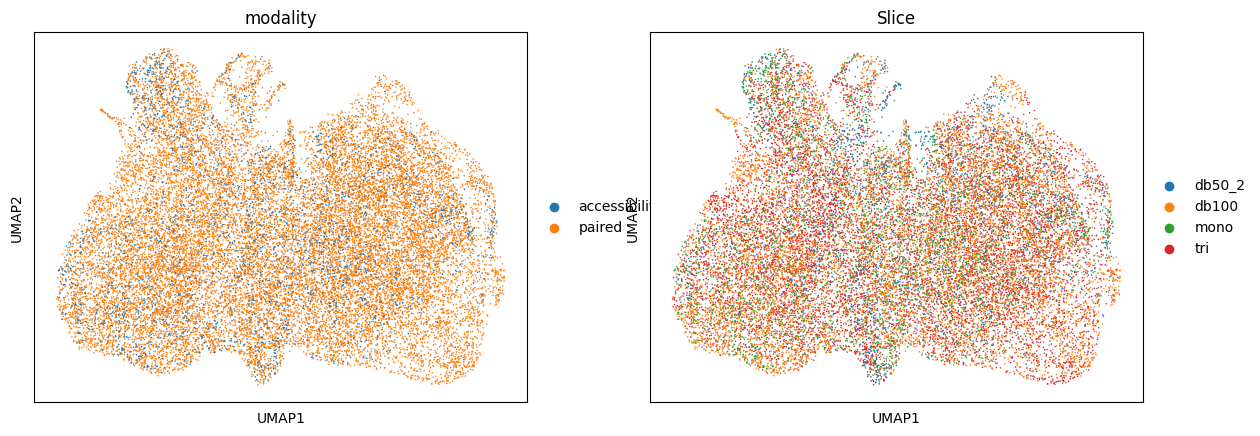

In [60]:
sc.pl.umap(adata_mvi, color=['modality', 'Slice'])

In [77]:
anal_dir = '../../../results/embeddings/MultiVI/DBiT-RnaAtac-Atac'
os.makedirs(anal_dir, exist_ok=True)

df = pd.DataFrame(latent, index=[x.rsplit('_', 1)[0] for x in adata_mvi.obs_names])
df.to_csv(join(anal_dir, 'df_emb.csv'))